In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import zipfile
import os

zip_path = "/content/dataset.zip"
extract_path = "/content/Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("/content/Dataset/dataset"))

['test', 'train']


In [ ]:
dataset_path = "/content/Dataset/dataset"

Classes Found:
['cloudy', 'rain', 'shine', 'sunrise']
cloudy: 250 training images
rain: 168 training images
shine: 206 training images
sunrise: 313 training images


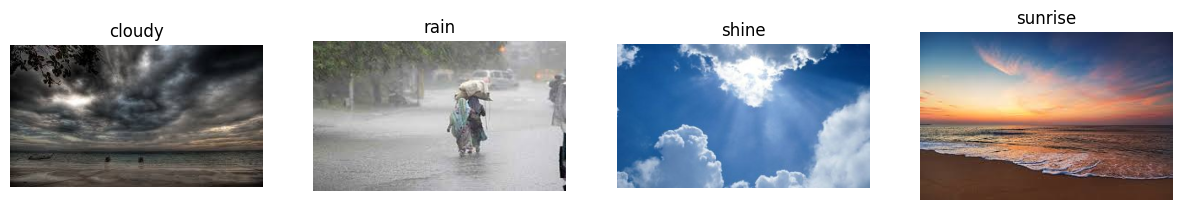

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

train_path = os.path.join(dataset_path, "train")

classes = sorted(os.listdir(train_path))

print("Classes Found:")
print(classes)

plt.figure(figsize=(15,5))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)

    images = os.listdir(class_path)

    print(f"{cls}: {len(images)} training images")

    img_path = os.path.join(class_path, images[0])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

X_train = []
y_train = []

X_test = []
y_test = []

# Dictionary for class labels
label_map = {cls: idx for idx, cls in enumerate(classes)}

print("Label Mapping:")
print(label_map)

# ----------- Load Training Images -----------
train_path = os.path.join(dataset_path, "train")

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        img = cv2.imread(image_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X_train.append(img)
        y_train.append(label_map[cls])


# ----------- Load Testing Images -----------
test_path = os.path.join(dataset_path, "test")

for cls in classes:
    class_path = os.path.join(test_path, cls)

    # Check if the class directory exists in the test set
    if not os.path.isdir(class_path):
        print(f"Warning: Test directory for class '{cls}' not found at '{class_path}'. Skipping.")
        continue

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        img = cv2.imread(image_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X_test.append(img)
        y_test.append(label_map[cls])


# Convert lists to NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("\nTraining Images :", len(X_train))
print("Testing Images  :", len(X_test))

Label Mapping:
{'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}

Training Images : 937
Testing Images  : 188


In [ ]:
# Flatten images into 1D vectors

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("Training Data Shape :", X_train_flat.shape)
print("Testing Data Shape  :", X_test_flat.shape)

Training Data Shape : (937, 49152)
Testing Data Shape  : (188, 49152)


In [ ]:
# Create Decision Tree model

dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

# Train the model

dt_model.fit(X_train_flat, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
# Predict on test data

y_pred = dt_model.predict(X_test_flat)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 69.68%


In [ ]:
print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))


Classification Report:

              precision    recall  f1-score   support

      cloudy       0.55      0.56      0.55        50
        rain       0.68      0.64      0.66        47
       shine       0.87      0.72      0.79        47
     sunrise       0.72      0.89      0.80        44

    accuracy                           0.70       188
   macro avg       0.71      0.70      0.70       188
weighted avg       0.70      0.70      0.70       188



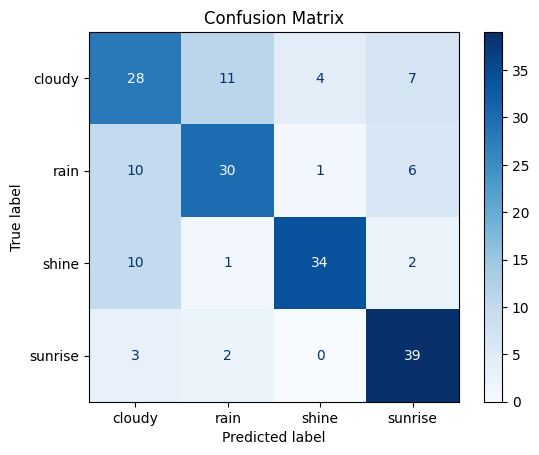

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=classes,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

Predicted Class: shine


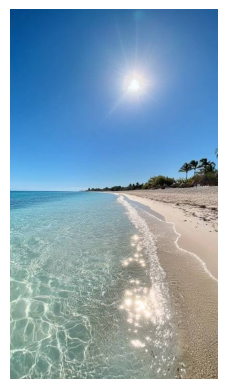

In [ ]:
image_path = "/content/test2.jpg"   # Change this

img = cv2.imread(image_path)

# Check if the image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file integrity.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")

    img = cv2.resize(img, (128,128))
    img = img / 255.0

    img = img.reshape(1, -1)

    prediction = dt_model.predict(img)

    predicted_class = classes[prediction[0]]

    print("Predicted Class:", predicted_class)